# Gate C0 — аудит последовательностей T1

**TL;DR.** Notebook читает только сохранённые machine artifacts Gate C0, ничего не
обучает и не обращается к `t1_v1/validation`, раскрытому `t1_v1/test` или будущему
holdout. Проверяются геометрия 911 forecast origins, causal masks, gaps и
пригодность компактных sequence-архитектур.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
ARTIFACT_ROOT = ROOT / "artifacts" / "model_selection" / "t1_gate_c0_sequence_audit_v1"
SPLIT_ROOT = ROOT / "artifacts" / "splits" / "t1_train_gate_c_v1"
FIGURE_ROOT = ARTIFACT_ROOT / "figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

report = json.loads((ARTIFACT_ROOT / "gate_c0_report.json").read_text(encoding="utf-8"))
validation = json.loads((ARTIFACT_ROOT / "validation_report.json").read_text(encoding="utf-8"))
lengths = pd.read_csv(ARTIFACT_ROOT / "sequence_length_distribution.csv")
gaps = pd.read_csv(ARTIFACT_ROOT / "sequence_gap_summary.csv")
architecture = pd.read_csv(ARTIFACT_ROOT / "architecture_eligibility.csv")
folds = pd.read_csv(ARTIFACT_ROOT / "fold_summary.csv")
sequence_manifest = pd.read_csv(SPLIT_ROOT / "sequence_manifest.csv")

assert report["status"] == "PASS_PROTOCOL_FROZEN"
assert validation["failed_checks"] == 0
assert report["model_training_calls"] == 0
assert report["historical_validation_loaded"] is False
assert report["current_t1_test_loaded"] is False
assert len(sequence_manifest) == 911

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Источники: machine artifacts Gate C0; model training calls =", report["model_training_calls"])

Источники: machine artifacts Gate C0; model training calls = 0


## Контекст и метод

Sequence representation строится по одной точке и заканчивается на `current_date`.
Observation после origin и target observation запрещены. До длины 16 используется
left padding; идентификаторы сохранены только как metadata и не входят в сеть.
Fold provenance наследует неизменяемые 11 rolling, 42 leave-profile-out и 12
leave-zone-out outer folds Gate B5; у каждого outer fold остаются три inner folds.

In [2]:
key_facts = pd.DataFrame([
    ("Forecast origins", report["data"]["origins"]),
    ("Траектории точек", report["data"]["points"]),
    ("Профили", report["data"]["profiles"]),
    ("Зоны", report["data"]["zones"]),
    ("Длина истории, min/median/max", f'{report["data"]["history_length_min"]} / {report["data"]["history_length_median"]:.0f} / {report["data"]["history_length_max"]}'),
    ("Положительный delta_t, min/median/max, дней", f'{report["data"]["delta_t_days_min_positive"]} / {report["data"]["delta_t_days_median_positive"]:.0f} / {report["data"]["delta_t_days_max"]}'),
    ("Future observations во входах", report["sequence_contract"]["future_observations_in_inputs"]),
    ("Target observations во входах", report["sequence_contract"]["target_observations_in_inputs"]),
], columns=["Показатель", "Значение"])
display(key_facts)

,Показатель,Значение
0,Forecast origins,911
1,Траектории точек,98
2,Профили,14
3,Зоны,4
4,"Длина истории, min/median/max",3 / 7 / 16
5,"Положительный delta_t, min/median/max, дней",42 / 168 / 560
6,Future observations во входах,0
7,Target observations во входах,0


## Данные: длина истории и padding

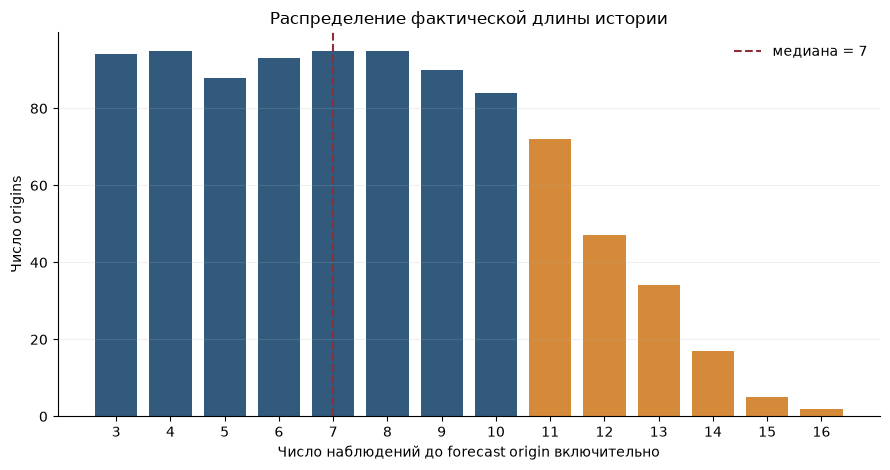

In [3]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
colors = ["#315A7D" if value <= 10 else "#D58A3A" for value in lengths["history_length"]]
ax.bar(lengths["history_length"], lengths["origins"], color=colors, width=0.78)
ax.axvline(report["data"]["history_length_median"], color="#8C2F39", linestyle="--", linewidth=1.5, label="медиана = 7")
ax.set_title("Распределение фактической длины истории")
ax.set_xlabel("Число наблюдений до forecast origin включительно")
ax.set_ylabel("Число origins")
ax.set_xticks(lengths["history_length"])
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "01_sequence_length_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

История существенно короче типичных контекстов современных transformer-моделей:
более половины origins имеют не более семи наблюдений, а длина 15–16 встречается
только у семи origins. Поэтому compact recurrent/causal convolution models являются
обязательным первым screen, а patch-based architectures исключены заранее.

## Нерегулярность календаря и пропущенные кампании

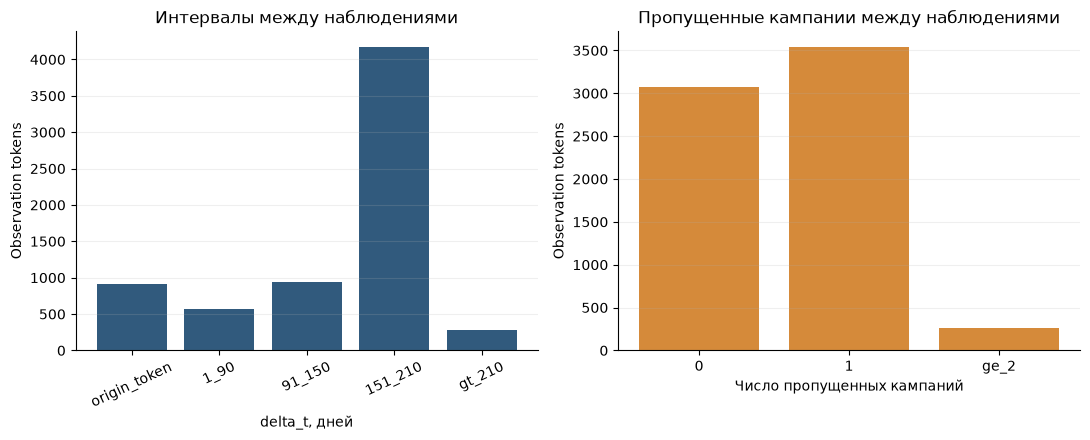

In [4]:
gap_days = gaps[gaps["dimension"].eq("gap_days")].copy()
gap_order = ["origin_token", "1_90", "91_150", "151_210", "gt_210"]
gap_days["segment"] = pd.Categorical(gap_days["segment"], gap_order, ordered=True)
gap_days = gap_days.sort_values("segment")
missing = gaps[gaps["dimension"].eq("missing_campaigns")].copy()
missing["segment"] = pd.Categorical(missing["segment"], ["0", "1", "ge_2"], ordered=True)
missing = missing.sort_values("segment")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.5))
axes[0].bar(gap_days["segment"].astype(str), gap_days["observation_tokens"], color="#315A7D")
axes[0].set_title("Интервалы между наблюдениями")
axes[0].set_xlabel("delta_t, дней")
axes[0].set_ylabel("Observation tokens")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(missing["segment"].astype(str), missing["observation_tokens"], color="#D58A3A")
axes[1].set_title("Пропущенные кампании между наблюдениями")
axes[1].set_xlabel("Число пропущенных кампаний")
axes[1].set_ylabel("Observation tokens")
axes[1].grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "02_gap_and_missingness_geometry.png", dpi=220, bbox_inches="tight")
plt.show()

Медианный положительный интервал равен 168 дням, диапазон — 42–560 дней. У 243
origins в истории есть интервал с двумя и более пропущенными кампаниями. Это делает
`delta_t`, uncertainty и missingness masks обязательными входами; интерполяция на
равномерную сетку не вводится без отдельного доказательного этапа.

## Architecture pre-screen

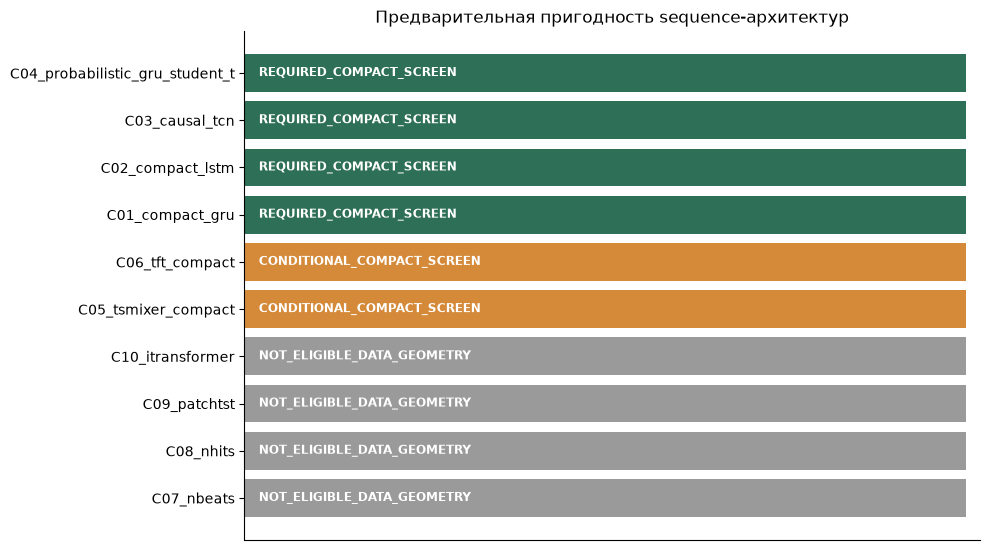

,model_id,family,status,condition,reason
0,C01_compact_gru,gated_recurrent_unit,REQUIRED_COMPACT_SCREEN,NaN,NaN
1,C02_compact_lstm,long_short_term_memory,REQUIRED_COMPACT_SCREEN,NaN,NaN
2,C03_causal_tcn,temporal_convolutional_network,REQUIRED_COMPACT_SCREEN,NaN,NaN
3,C04_probabilistic_gru_student_t,irregular_time_probabilistic_recurrent,REQUIRED_COMPACT_SCREEN,NaN,NaN
4,C05_tsmixer_compact,time_series_mixer,CONDITIONAL_COMPACT_SCREEN,masked_fixed_length_representation_passes_c0_a...,NaN
5,C06_tft_compact,temporal_fusion_transformer,CONDITIONAL_COMPACT_SCREEN,parameter_count_lte_100000_and_no_identifier_e...,NaN
6,C07_nbeats,n_beats,NOT_ELIGIBLE_DATA_GEOMETRY,NaN,requires_unjustified_regular_grid_or_interpola...
7,C08_nhits,n_hits,NOT_ELIGIBLE_DATA_GEOMETRY,NaN,hierarchical_downsampling_not_identifiable_on_...
8,C09_patchtst,patch_time_series_transformer,NOT_ELIGIBLE_DATA_GEOMETRY,NaN,patch_context_is_too_short_and_sparse_without_...
9,C10_itransformer,inverted_transformer,NOT_ELIGIBLE_DATA_GEOMETRY,NaN,sample_and_channel_geometry_is_insufficient_fo...


In [5]:
status_order = ["REQUIRED_COMPACT_SCREEN", "CONDITIONAL_COMPACT_SCREEN", "NOT_ELIGIBLE_DATA_GEOMETRY"]
status_color = {
    "REQUIRED_COMPACT_SCREEN": "#2E6F57",
    "CONDITIONAL_COMPACT_SCREEN": "#D58A3A",
    "NOT_ELIGIBLE_DATA_GEOMETRY": "#9A9A9A",
}
plot_arch = architecture.copy()
plot_arch["status_rank"] = plot_arch["status"].map({value: index for index, value in enumerate(status_order)})
plot_arch = plot_arch.sort_values(["status_rank", "model_id"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(10.0, 5.6))
ax.barh(plot_arch["model_id"], np.ones(len(plot_arch)), color=plot_arch["status"].map(status_color))
ax.set_xlim(0, 1.02)
ax.set_xticks([])
ax.set_title("Предварительная пригодность sequence-архитектур")
for index, row in enumerate(plot_arch.itertuples(index=False)):
    ax.text(0.02, index, row.status, va="center", ha="left", color="white", fontsize=8.5, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "03_architecture_eligibility.png", dpi=220, bbox_inches="tight")
plt.show()

display(architecture[["model_id", "family", "status", "condition", "reason"]])

## Fold geometry и leakage controls

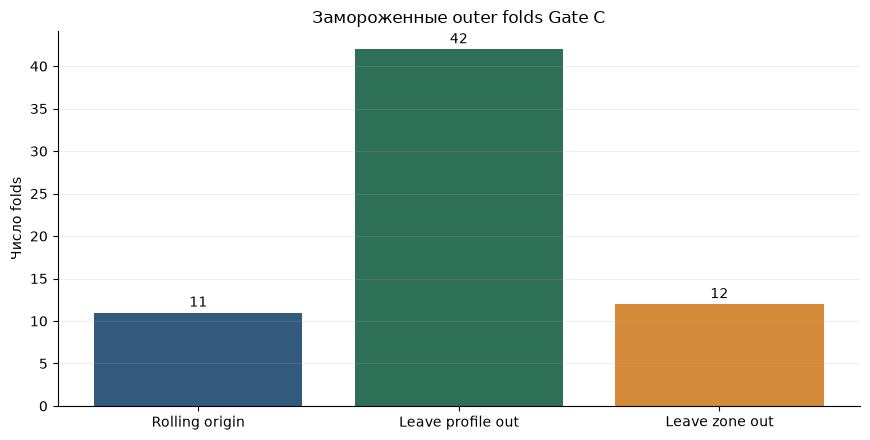

,level,design,folds,train_origins_min,train_origins_median,train_origins_max,validation_origins_min,validation_origins_median,validation_origins_max,all_forward_only,all_held_groups_excluded
0,inner,rolling_origin,33,205,503.0,809,12,15.0,91,True,True
1,inner,spatiotemporal_leave_profile_out,126,452,580.0,772,6,14.0,84,True,True
2,inner,spatiotemporal_leave_zone_out,36,225,462.5,735,4,14.0,83,True,True
3,outer,rolling_origin,11,316,606.0,823,12,84.0,91,True,True
4,outer,spatiotemporal_leave_profile_out,42,558,671.0,786,3,7.0,7,True,True
5,outer,spatiotemporal_leave_zone_out,12,333,548.5,749,7,20.5,40,True,True


In [6]:
outer = folds[folds["level"].eq("outer")].copy()
label_map = {
    "rolling_origin": "Rolling origin",
    "spatiotemporal_leave_profile_out": "Leave profile out",
    "spatiotemporal_leave_zone_out": "Leave zone out",
}
outer["label"] = outer["design"].map(label_map)
fig, ax = plt.subplots(figsize=(8.8, 4.5))
bars = ax.bar(outer["label"], outer["folds"], color=["#315A7D", "#2E6F57", "#D58A3A"])
ax.set_title("Замороженные outer folds Gate C")
ax.set_ylabel("Число folds")
ax.grid(axis="y", alpha=0.2)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.7, f"{int(bar.get_height())}", ha="center")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "04_fold_design.png", dpi=220, bbox_inches="tight")
plt.show()

display(folds)
assert folds["all_forward_only"].all()
assert folds["all_held_groups_excluded"].all()

## Выводы

1. Представление `t1_train_gate_c_v1` пригодно для компактного GRU/LSTM/TCN и
   probabilistic recurrent screen, но не обосновывает тяжёлые patch-transformers.
2. Нерегулярность 42–560 дней и missing-campaign gaps требуют явных time/gap masks.
3. Все preprocessing и early stopping operations должны оставаться внутри fold train /
   nested inner validation; старые validation/test недоступны runner.
4. Gate C0 не даёт нового результата качества. Следующий этап — C1 compact screen с
   пятью seeds и B1/B7/B8 как неизменяемыми comparators.
5. Без нового future/external holdout окончательная научная оценка остаётся
   `PENDING_DATA`.